# Data Collection

##Scrape voting data from DW-Nominate's API:



In [ ]:
# Necessary imports and installs for this portion:
!pip install PyPDF2

import pandas as pd
import requests
import time
import re
import PyPDF2
import io

In [ ]:
# Data collection - we want to scrape vote data from DW-Nominate, (https://voteview.com/)
# speech data from Congress.gov API OR ProPublica Congress API TODO - find
# Campaign finance data from FEC too, Integrity index...

url = "https://voteview.com/static/data/out/members/Hall_members.csv"
df = pd.read_csv(url)

#Given computational expenses, we'll only use data from the 118th congress (2023-2024)

#Using the last four congress
congresses =  [118]
current_members = df[df['congress'].isin(congresses)].copy()

# Clean up party codes
party_map = {100: 'Democrat', 200: 'Republican', 328: 'Independent'}
current_members['party_name'] = current_members['party_code'].map(party_map)


# some mebers of congress, e.g. Rep Raul Grijalva (who cast only 1 vote), died early enough in the term to be a giant outlier
# therefore, we want to filter this data so a member has at least 30 votes
df_members_clean = current_members[current_members['nominate_number_of_votes'] > 30]
df_members_clean.to_csv('members.csv')

Next, we want to scrape all PDFs from the congressional record and process them to exttact the speeches

## Scraping Congressional records

WARNING: The below code takes approximately two hours to run

In [ ]:

API_KEY = "9xPYJbCVyyKhe8R18h4nSn9bBi7Cf5w185MMx9vk"

#matching speakers obtained from scraping to members from the Voteview DF
def match_speaker_to_member_voteview(speaker_lastname, members_df, congress='118'):
    if not speaker_lastname:
        return None

    speaker_lastname = speaker_lastname.upper()

    relevant_members = members_df[
        (members_df['congress'] == int(congress)) &
        (members_df['chamber'] == 'House')
    ]

    for idx, member in relevant_members.iterrows():
        bioname = member.get('bioname', '')

        if ',' in bioname:
            last_name = bioname.split(',')[0].strip().upper()

            if last_name == speaker_lastname:
                return {
                    'bioname': member.get('bioname'),
                    'bioguide_id': member.get('bioguide_id'),
                    'party': member.get('party_name'),
                    'state_abbrev': member.get('state_abbrev'),
                    'district_code': member.get('district_code'),
                    'icpsr': member.get('icpsr'),
                    'nominate_dim1': member.get('nominate_dim1'),
                    'nominate_dim2': member.get('nominate_dim2')
                }

    return None

#getting all URLs to congressional record PDFs using the congress.gov API
def get_house_pdf_urls(start_date="2023-01-03", end_date="2023-12-31", congress='118'):
    all_house_records = []
    url = "https://api.congress.gov/v3/congressional-record"
    offset = 0

    print("Fetching Congressional Record issues...")

    while True:
        params = {
            'api_key': API_KEY,
            'offset': offset,
            'limit': 250,
            'format': 'json'
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            break

        data = response.json()

        if 'Results' not in data or 'Issues' not in data['Results']:
            break

        issues = data['Results']['Issues']

        if not issues:
            break

        for issue in issues:
            pub_date = issue.get('PublishDate', '')
            issue_congress = issue.get('Congress', '')

            if pub_date and start_date <= pub_date <= end_date and issue_congress == congress:
                links = issue.get('Links', {})

                if 'House' in links and 'PDF' in links['House']:
                    pdf_url = links['House']['PDF'][0].get('Url', '')

                    record = {
                        'date': pub_date,
                        'congress': issue_congress,
                        'volume': issue.get('Volume', ''),
                        'issue_num': issue.get('Issue', ''),
                        'house_pdf_url': pdf_url
                    }

                    all_house_records.append(record)

        print(f"  Offset {offset}: {len(all_house_records)} House records found")

        offset += 250
        time.sleep(0.3)

        if offset >= 2000:
            break

    return pd.DataFrame(all_house_records)

#cleans the speaker name from the text so we can use it to match to a representative
def clean_speaker_name(speaker_raw):
    """Extract clean name from speaker text"""
    procedural_titles = [
        'The SPEAKER',
        'The CHAIR',
        'The CHAIRMAN',
        'SPEAKER pro tempore',
        'CHAIR pro tempore'
    ]

    for title in procedural_titles:
        if title in speaker_raw:
            return None

    match = re.search(r'(?:Mr\.|Mrs\.|Ms\.|Miss)\s+([A-Z][A-Z\'\-]+)', speaker_raw)

    if match:
        return match.group(1).strip()

    return None

# many speeches are very quick "I yeild to x person" style - we dont' want these in the model!
# the below code determins if they're not substantive enough
# I tinkered with this threshold a decent bit - 500 wound up filtering out most nonsense while keeping quick outbursts
def is_substantive_speech(speech_text, min_length=500):
    """Determine if a speech is substantive or just procedural"""
    if len(speech_text) < min_length:
        return False

    procedural_phrases = [
        'without objection',
        'the journal',
        'the pledge of allegiance',
        'the prayer',
        'point of order',
        'parliamentary inquiry',
        'i yield back',
        'i reserve the balance',
    ]

    text_lower = speech_text.lower()
    procedural_count = sum(1 for phrase in procedural_phrases if phrase in text_lower)

    #Also tinkered with this a bit - it's quite easy to hit
    # 'i yield back', and 'i reserve the balance' during a floor debate, but the third usually doesn't happen for non-substantive speech
    if procedural_count > 3:
        return False

    return True

#gets PDF using an agent
def download_pdf(pdf_url):
    """Download PDF from URL"""
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        response = requests.get(pdf_url, headers=headers, timeout=60)

        if response.status_code == 200:
            return response.content
        else:
            print(f"    Status code: {response.status_code}")
    except Exception as e:
        print(f"    Download error: {e}")

    return None

#uses PyPDF2 to et the speech from the next
def extract_text_from_pdf(pdf_content):
    """Extract text from PDF bytes"""
    try:
        pdf_file = io.BytesIO(pdf_content)
        pdf_reader = PyPDF2.PdfReader(pdf_file)

        text = ""
        for page in pdf_reader.pages:
            text += page.extract_text() + "\n"

        return text
    except Exception as e:
        print(f"    PDF parse error: {e}")
        return None

# We didn't include Senate data in this analysis, so we just want to parse the house section
def extract_house_section(full_text):

    # Find the "House of Representatives" header (usually on page 1)
    # This is the actual section start, not mentions in prayers/speeches
    # Previous bug grabbed too much prayer text and made religious keywords dominate while erronesouly matching
    house_match = re.search(r'House of Representatives\s*\n\s*The House met', full_text, re.IGNORECASE)

    if house_match:
        # Start from this point
        house_start = house_match.start()

        # Find where the actual Senate section starts (look for Senate page markers S####)
        # Not just the word "Senate" which could be in speeches
        senate_section_match = re.search(r'\n\s*Senate\s*\n.*?S\d{4,5}', full_text[house_start:], re.DOTALL | re.IGNORECASE)

        if senate_section_match:
            # Found Senate section
            house_end = house_start + senate_section_match.start()
            return full_text[house_start:house_end]
        else:
            # No Senate section found, look for Extensions of Remarks
            extensions_match = re.search(r'EXTENSIONS OF REMARKS', full_text[house_start:], re.IGNORECASE)
            if extensions_match:
                house_end = house_start + extensions_match.start()
                return full_text[house_start:house_end]
            else:
                # Just return everything after House header
                return full_text[house_start:]

    # Fallback: look for H-page markers
    h_match = re.search(r'H\d{4,5}', full_text)
    if h_match:
        h_start = h_match.start()

        # Find first S-page marker
        s_match = re.search(r'S\d{4,5}', full_text[h_start:])
        if s_match:
            return full_text[h_start:h_start + s_match.start()]
        else:
            return full_text[h_start:]

    return None

# grab speeches and parse
def parse_speeches_from_text(text, date, members_df, congress='118'):
    """Parse speeches from House text with member matching"""
    if not text:
        return []

    speeches = []

    # Speaker pattern - looking for "Mr. LASTNAME" format
    # Nearly all recognitions in the house take the form "the chair reconizes the gentleman/gentallay from [state], Ms./Mr. [last name] "
    speech_pattern = r'\n\s*((?:Mr\.|Mrs\.|Ms\.|Miss)\s+[A-Z][A-Z\'\-]+(?:\s+of\s+[A-Za-z\s]+)?)\.\s+'

    parts = re.split(speech_pattern, text)

    for i in range(1, len(parts), 2):
        if i + 1 < len(parts):
            speaker_raw = parts[i].strip()
            speech_text = parts[i + 1].strip()

            # Clean up the text
            speech_text = re.sub(r'\s+', ' ', speech_text)

            # Remove page headers
            speech_text = re.sub(r'H\d+\s+CONGRESSIONAL RECORD[—\-]+HOUSE.*?(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d+,\s+\d{4}', '', speech_text)

            # Extract clean speaker name
            speaker_lastname = clean_speaker_name(speaker_raw)

            # Skip if procedural speaker
            if not speaker_lastname:
                continue

            # Check if it's a substantive speech
            if not is_substantive_speech(speech_text, min_length=300):
                continue

            # Match to member
            member_info = match_speaker_to_member_voteview(speaker_lastname, members_df, congress)

            speech_record = {
                'date': date,
                'speaker_raw': speaker_raw,
                'speaker_lastname': speaker_lastname,
                'text': speech_text[:10000],  # Store more text
                'text_length': len(speech_text)
            }

            # Add member info if found
            if member_info:
                speech_record.update({
                    'bioname': member_info['bioname'],
                    'bioguide_id': member_info['bioguide_id'],
                    'party': member_info['party'],
                    'state_abbrev': member_info['state_abbrev'],
                    'district_code': member_info['district_code'],
                    'icpsr': member_info['icpsr'],
                    'nominate_dim1': member_info['nominate_dim1'],
                    'nominate_dim2': member_info['nominate_dim2']
                })
            else:
                speech_record.update({
                    'bioname': None,
                    'bioguide_id': None,
                    'party': None,
                    'state_abbrev': None,
                    'district_code': None,
                    'icpsr': None,
                    'nominate_dim1': None,
                    'nominate_dim2': None
                })

            speeches.append(speech_record)

    return speeches

# The below code is configured to scrape multiple congresses, but we used it for only one after encountering many computer limitations
def scrape_all_house_speeches_multi_congress(congresses=[116, 117, 118, 119], limit_per_congress=None, debug_mode=False):
    """
    Scrape speeches from multiple congresses
    """

    # Step 0: Load members data
    print("\n" + "="*60)
    print("STEP 0: Loading Voteview members data")
    print("="*60)
    members_df = df_members_clean
    print(f"✓ Loaded {len(members_df)} members across congresses {congresses}")

    # Congress date ranges
    congress_dates = {
        116: ("2019-01-03", "2021-01-03"),
        117: ("2021-01-03", "2023-01-03"),
        118: ("2023-01-03", "2025-01-03"),
        119: ("2025-01-03", "2027-01-03")
    }

    all_speeches = []

    for congress in congresses:
        print(f"\n{'='*60}")
        print(f"PROCESSING {congress}TH CONGRESS")
        print('='*60)

        if congress not in congress_dates:
            print(f"⚠ No date range defined for {congress}th Congress, skipping...")
            continue

        start_date, end_date = congress_dates[congress]

        # Step 1: Get all House PDF URLs for this congress
        print(f"\nGetting House session dates for {congress}th Congress...")
        df_urls = get_house_pdf_urls(start_date, end_date, congress=str(congress))

        if len(df_urls) == 0:
            print(f"No House sessions found for {congress}th Congress!")
            continue

        print(f"✓ Found {len(df_urls)} House sessions")

        # Step 2: Construct PDF URLs
        df_urls['pdf_url'] = df_urls['date'].apply(lambda d: f"https://www.govinfo.gov/content/pkg/CREC-{d}/pdf/CREC-{d}.pdf")

        # Step 3: Download and parse PDFs
        df_to_process = df_urls.head(limit_per_congress) if limit_per_congress else df_urls

        for idx, row in df_to_process.iterrows():
            date = row['date']
            pdf_url = row['pdf_url']

            print(f"\nProcessing {date}... ({idx+1}/{len(df_to_process)})")

            # Download PDF
            pdf_content = download_pdf(pdf_url)

            if not pdf_content:
                print(f"  ✗ Download failed")
                continue

            print(f"  ✓ Downloaded ({len(pdf_content):,} bytes)")

            # Extract text
            full_text = extract_text_from_pdf(pdf_content)

            if not full_text:
                print(f"  ✗ Text extraction failed")
                continue

            print(f"  ✓ Extracted text ({len(full_text):,} chars)")

            # Debug mode - save the full text for problematic dates
            if debug_mode:
                with open(f'debug_full_{date}.txt', 'w', encoding='utf-8') as f:
                    f.write(full_text)
                print(f"  💾 Saved full text to debug_full_{date}.txt")

            # Extract House section
            house_text = extract_house_section(full_text)

            if not house_text:
                print(f"  ✗ No House section found")
                continue
            else:
                print(f"  ✓ Extracted House section ({len(house_text):,} chars)")

            # Parse speeches
            speeches = parse_speeches_from_text(house_text, date, members_df, congress=str(congress))
            all_speeches.extend(speeches)

            print(f"  ✓ Extracted {len(speeches)} speeches")

            if speeches:
                print(f"    Sample: {speeches[0]['speaker_lastname']} - {speeches[0].get('bioname', 'NO MATCH')}")
            elif len(house_text) > 50000:
                # Should have found speeches in a large text
                print(f"  ⚠ Large text ({len(house_text):,} chars) but no speeches found")
                if debug_mode:
                    with open(f'debug_house_{date}.txt', 'w', encoding='utf-8') as f:
                        f.write(house_text[:100000])  # First 100k chars
                    print(f"  💾 Saved house section to debug_house_{date}.txt")

            time.sleep(1)  # Be polite to the server

    # Create DataFrame
    df_speeches = pd.DataFrame(all_speeches)

    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Total speeches: {len(df_speeches)}")

    if len(df_speeches) > 0:
        print(f"Date range: {df_speeches['date'].min()} to {df_speeches['date'].max()}")
        print(f"Unique speakers: {df_speeches['speaker_lastname'].nunique()}")

        print(f"\nSpeeches by congress:")
        df_speeches['congress'] = df_speeches['date'].apply(lambda d:
            119 if d >= "2025-01-03" else
            118 if d >= "2023-01-03" else
            117 if d >= "2021-01-03" else
            116 if d >= "2019-01-03" else None
        )
        print(df_speeches['congress'].value_counts().sort_index())

        print(f"\nTop 10 speakers overall:")
        print(df_speeches['speaker_lastname'].value_counts().head(10))

        print(f"\nMatching statistics:")
        matched = df_speeches['bioguide_id'].notna().sum()
        total = len(df_speeches)
        print(f"  Matched to members: {matched}/{total} ({100*matched/total:.1f}%)")

        if df_speeches['bioguide_id'].isna().sum() > 0:
            print(f"\nTop 10 unmatched speakers:")
            unmatched = df_speeches[df_speeches['bioguide_id'].isna()]['speaker_lastname'].value_counts().head(10)
            print(unmatched)

    return df_speeches




df_speeches = scrape_all_house_speeches_multi_congress(
    congresses=[118],
    limit_per_congress=None,
    debug_mode=False
)
df_speeches.to_csv("speeches118.csv")

## Cleaning obtained speeches

Next, we found that the speeches we obtained contained many errors and parsing text that the initial pass through missed. We also added a litany of stop words and other agressive cleaning mechanisms to remove filler

In [ ]:
#returning from the run of the above function - clean2 was cleaned with the pre-revised clean function
df_speeches = pd.read_csv('118th_speeches_clean2.csv')

In [ ]:
#filtering to speakers who gave at least 10 speeches
speaker_counts = df_speeches['bioname'].value_counts()
df_speeches_final = df_speeches[df_speeches['bioname'].map(speaker_counts) > 10]

In [ ]:
# this code went through multiple iterations -
# the latest one here agressively targets many phrases we found caused issues in the machine learning model
# many parsing errors were corrected here, as this code takes about 7 minutes to run (compared to many hours for the text parser)

def aggressive_clean_congressional_speech(text):
    """
    Remove ALL procedural language, names, places, and non-substantive content
    """
    if pd.isna(text) or len(str(text).strip()) == 0:
        return ""

    text = str(text).lower()

    # Remove procedural phrases


    procedural_patterns = [
        # Yielding time
        r'\bi\s+yield\s+(?:back|to|the\s+balance|my\s+time|the\s+remainder)\b.*?(?:\.|$)',
        r'\byield(?:s|ing)?\s+back\b',
        r'\breserve\s+the\s+balance\s+of\s+(?:my|his|her)\s+time\b',
        r'\btime\s+(?:has\s+)?expired\b',
        r'\breclaim(?:ing)?\s+my\s+time\b',

        # Addressing others
        r'\b(?:mr|ms|mrs|miss|madam)\s+(?:speaker|chairman|chairwoman|chair|president|presiding\s+officer)\b',
        r'\b(?:the\s+)?(?:gentleman|gentlewoman|gentlelady)\s+(?:from|of|representing)\s+\w+\b',
        r'\b(?:my\s+)?(?:distinguished\s+)?(?:colleague|friend)\s+from\s+\w+\b',
        r'\bacting\s+chair(?:man|woman|person)?\b',

        # Parliamentary procedure
        r'\bpoint\s+of\s+(?:order|inquiry|personal\s+privilege)\b',
        r'\bparliamentary\s+inquiry\b',
        r'\bi\s+(?:rise|stand)\s+in\s+(?:support|opposition)\b',
        r'\bi\s+(?:thank|recognize|acknowledge)\s+the\s+(?:gentleman|gentlewoman)\b',
        r'\bask\s+unanimous\s+consent\b',
        r'\bwithout\s+objection\b',
        r'\bobjection\s+(?:is\s+)?heard\b',
        r'\bthe\s+(?:clerk|speaker|chair)\s+will\b',
        r'\bwill\s+the\s+(?:gentleman|gentlewoman)\s+yield\b',

        # Voting/procedural actions
        r'\bvote\s+(?:on|for|against)\s+(?:the\s+)?(?:motion|amendment|bill|resolution)\b',
        r'\b(?:aye|nay|yea|nay)s?\s+(?:are|have|it)\b',
        r'\brecorded\s+vote\b',
        r'\broll\s+call\s+vote\b',
        r'\bquorum\s+call\b',

        # References to bills/amendments (keep policy content, remove procedural refs)
        r'\b(?:h\.?r\.?|s\.?)\s*\d+\b',  # H.R. 1234, S. 5678
        r'\bamendment\s+(?:number\s+)?\d+\b',
        r'\bsection\s+\d+\b',
        r'\bsubsection\s+[a-z]\b',
        r'\bpage\s+\d+\b',
        r'\bline\s+\d+\b',

        # Time references
        r'\b\d+\s+(?:second|minute|hour)s?\b',
        r'\b(?:one|two|three|four|five)\s+(?:minute|hour)s?\b',

        # Generic transitions/fillers
        r'\bi\s+(?:thank|appreciate|want\s+to\s+thank)\b',
        r'\bin\s+conclusion\b',
        r'\blet\s+me\s+(?:say|begin|start|conclude)\b',
        r'\bi\s+want\s+to\s+(?:talk|speak|discuss)\s+about\b',
    ]

    for pattern in procedural_patterns:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)


    # 2. Removing ALL geographic references (clogging up data too much)

    # States (full names and abbreviations)
    states_full = [
        'alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado',
        'connecticut', 'delaware', 'florida', 'georgia', 'hawaii', 'idaho',
        'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana',
        'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota',
        'mississippi', 'missouri', 'montana', 'nebraska', 'nevada',
        'new hampshire', 'new jersey', 'new mexico', 'new york',
        'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon',
        'pennsylvania', 'rhode island', 'south carolina', 'south dakota',
        'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington',
        'west virginia', 'wisconsin', 'wyoming', 'puerto rico', 'guam',
        'virgin islands', 'american samoa', 'district of columbia', 'washington dc'
    ]

    for state in states_full:
        text = re.sub(r'\b' + state + r'\b', ' ', text)

    # State abbreviations
    state_abbrevs = [
        'al', 'ak', 'az', 'ar', 'ca', 'co', 'ct', 'de', 'fl', 'ga',
        'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky', 'la', 'me', 'md',
        'ma', 'mi', 'mn', 'ms', 'mo', 'mt', 'ne', 'nv', 'nh', 'nj',
        'nm', 'ny', 'nc', 'nd', 'oh', 'ok', 'or', 'pa', 'ri', 'sc',
        'sd', 'tn', 'tx', 'ut', 'vt', 'va', 'wa', 'wv', 'wi', 'wy', 'dc', 'pr'
    ]

    for abbrev in state_abbrevs:
        text = re.sub(r'\b' + abbrev + r'\b', ' ', text)

    # Major cities
    cities = [
        'houston', 'detroit', 'chicago', 'dallas', 'austin', 'boston',
        'seattle', 'atlanta', 'miami', 'denver', 'phoenix', 'philadelphia',
        'san diego', 'san francisco', 'los angeles', 'new york', 'baltimore',
        'memphis', 'nashville', 'charlotte', 'indianapolis', 'columbus',
        'milwaukee', 'kansas city', 'las vegas', 'portland', 'sacramento',
        'san antonio', 'pittsburgh', 'cleveland', 'cincinnati', 'minneapolis',
        'orlando', 'tampa', 'st louis', 'raleigh', 'omaha', 'tulsa',
        'albuquerque', 'tucson', 'fresno', 'mesa', 'virginia beach',
        'oakland', 'miami', 'wichita', 'arlington', 'new orleans'
    ]

    # while this may limit info drawing from phrases like "New York is a communist hellhole",
    # too many references like "Mr. Speaker, [hometown] is a great place to live"

    for city in cities:
        text = re.sub(r'\b' + city + r'\b', ' ', text)

    # Remove ALL person names/titles

    # Titles
    titles = ['mr', 'ms', 'mrs', 'miss', 'dr', 'prof', 'sen', 'senator',
              'rep', 'representative', 'congressman', 'congresswoman',
              'speaker', 'chairman', 'chairwoman', 'chair', 'president',
              'vice', 'secretary', 'attorney', 'general', 'governor',
              'mayor', 'justice', 'judge']

    for title in titles:
        text = re.sub(r'\b' + title + r'\b\.?', ' ', text)

    # Common political last names
    # appearing too much as noise in results
    political_names = [
        'biden', 'trump', 'obama', 'bush', 'clinton', 'reagan',
        'pelosi', 'mccarthy', 'mcconnell', 'schumer', 'cheney',
        'putin', 'xi', 'kennedy',
    ]

    for name in political_names:
        text = re.sub(r'\b' + name + r'\b', ' ', text)

    # Remove standalone letters (often scraping artifacts)
    text = re.sub(r'\b[a-z]\b', ' ', text)



    # 5. Remove numbers and dates
    # this was a hard call to make, but we felt confident in doing it because phrases like
    # "January 6th" or "2020 Election" did not appear to the degree we expected at all, and instead
    # noise from the congressional record was getting through too much

    # Years
    text = re.sub(r'\b(?:19|20)\d{2}\b', ' ', text)

    # Numbers
    text = re.sub(r'\b\d+(?:,\d+)*(?:\.\d+)?\b', ' ', text)

    # Ordinals (1st, 2nd, 3rd, 118th, etc.)
    text = re.sub(r'\b\d+(?:st|nd|rd|th)\b', ' ', text)


    # Clean up whitespace

    # Multiple spaces to single space
    text = re.sub(r'\s+', ' ', text)

    # Remove very short words (likely artifacts)
    words = text.split()
    words = [w for w in words if len(w) >= 3]  # Keep only words 3+ chars

    text = ' '.join(words)

    return text.strip()

# STEP 2: progress bar

from tqdm import tqdm
tqdm.pandas()

df_speeches_final['text_super_clean'] = df_speeches_final['text'].progress_apply(
    aggressive_clean_congressional_speech
)
df_speeches_final.to_csv('118_final_clean_speeches_with_ideology3.csv', index=False)

100%|██████████| 23091/23091 [06:02<00:00, 63.78it/s]


## Running ML to generate 'Authenticity Gap'

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================
# STEP 0: Load merged data
# ========================================

df = pd.read_csv('118_final_clean_speeches_with_ideology3.csv')

print(f"Total speeches: {len(df)}")
print(f"Speeches with NOMINATE scores: {df['nominate_dim1'].notna().sum()}")

# Remove speeches without ideology scores
df_model = df[df['nominate_dim1'].notna()].copy()
print(f"Using {len(df_model)} speeches for modeling")

# ========================================
# STEP 1: Basic statistics about ideology
# ========================================

print("\n" + "="*60)
print("IDEOLOGY DISTRIBUTION")
print("="*60)

print(f"\nNOMINATE Dim 1 (Liberal-Conservative):")
print(f"  Mean: {df_model['nominate_dim1'].mean():.3f}")
print(f"  Std: {df_model['nominate_dim1'].std():.3f}")
print(f"  Min: {df_model['nominate_dim1'].min():.3f}")
print(f"  Max: {df_model['nominate_dim1'].max():.3f}")

print(f"\nBy party:")
party_stats = df_model.groupby('party')['nominate_dim1'].agg(['mean', 'std', 'count'])
print(party_stats)

# Step 2: Visualize and save distribution of ideology data
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df_model['nominate_dim1'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('NOMINATE Dim 1')
plt.ylabel('Number of Speeches')
plt.title('Distribution of Ideology Scores')

plt.subplot(1, 2, 2)
for party in df_model['party'].unique():
    if pd.notna(party):
        party_data = df_model[df_model['party'] == party]['nominate_dim1']
        plt.hist(party_data, bins=20, alpha=0.5, label=party)
plt.xlabel('NOMINATE Dim 1')
plt.ylabel('Number of Speeches')
plt.title('Ideology by Party')
plt.legend()
plt.tight_layout()
plt.savefig('ideology_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# Step 3: Remove speeches that are now too short (likely just procedural)
min_length = 100  # At least 100 characters after cleaning
df_model = df_model[df_model['text_super_clean_length'] >= min_length].copy()

print(f"  Speeches after removing too-short: {len(df_model)}")

# STEP 4: More stop words!

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# using sklearn's English stop words
custom_stop_words = set(ENGLISH_STOP_WORDS)

# Add congress-specific stop words
congressional_stops = {
    # Procedural
    'gentleman', 'gentlewoman', 'gentlelady', 'colleague', 'friend',
    'yield', 'time', 'minutes', 'seconds', 'hour', 'hours',
    'thank', 'thanks', 'appreciate', 'gratitude', 'honored',
    'rise', 'stand', 'speak', 'speaking', 'talk', 'talking',
    'support', 'supporting', 'supported', 'oppose', 'opposing', 'opposed',
    'recognize', 'recognizes', 'member', 'member control', 'pursuant', 'pursuant house',

    # Generic political terms (non-ideological)
    'people', 'nation', 'national',
    'country', 'united', 'states', 'federal',
    'today', 'year', 'years', 'day', 'days', 'week', 'weeks', 'month', 'months',
    'important', 'critical', 'essential', 'necessary', 'need', 'needs',
    'make', 'makes', 'making', 'made', 'ensure', 'ensur', 'ensuring',
    'work', 'working', 'works', 'worked', 'yeild', 'yeilding', 'adoption',
    'urge adoption',

    # Procedural legislative terms
    'bill', 'bills', 'legislation', 'amendment', 'amendments',
    'resolution', 'act', 'law', 'laws', 'statute',
    'vote', 'votes', 'voting', 'voted',
    'pass', 'passed', 'passing', 'passage',

    # Discourse markers (non-substantive)
     'said', 'say', 'says', 'saying',
    'know', 'knows', 'known', 'knowing',
    'think', 'thinks', 'thought', 'thinking',
    'believe', 'believes', 'believed', 'believing',
    'want', 'wants', 'wanted', 'wanting',
    'going', 'come', 'comes', 'coming',
    'let', 'lets', 'make', 'makes',
    'way', 'ways', 'thing', 'things',
    'issue', 'issues', 'matter', 'matters',
    'question', 'questions', 'answer', 'answers',

    # Vague quantifiers
    'many', 'much', 'lot', 'lots', 'number', 'several',
    'various', 'different', 'certain',

    # Time references we missed
    'yesterday', 'tomorrow', 'tonight', 'today',
    'recently', 'currently', 'now', 'ago',

    # Common verbs (too generic, screwing with results)
    'have', 'has', 'had', 'having',
    'do', 'does', 'did', 'doing', 'done',
    'get', 'gets', 'got', 'getting', 'gotten',
    'take', 'takes', 'took', 'taken', 'taking',
    'give', 'gives', 'gave', 'given', 'giving',

    # Meta-references to the speech itself
    'read', 'reading', 'considered', 'discussion',
    'debate', 'debating', 'argued', 'arguing',

    # Names of floor-managers (often referred to in debates)
    # Some of these are typo names missed where the first letter was
    # missed by a previous parser
    'ccollum', 'fernandez', 'delauro', 'elauro', 'pascrell',
    'mccormick', 'ccormick', 'mcgovern', 'cgovern', 'znuez',
    'mchenry', 'chenry', 'mccaul', 'ccaul', 'leger', 'zquez',
    'amalfa', 'mcclintock', 'cclintock', 'higgs', 'iggs'

    #miscellaneous typos and observed issues
    'shouldn', 'penn', 'jersey', 'gles'
}

custom_stop_words.update(congressional_stops)

# Convert to list for TfidfVectorizer
custom_stop_words = list(custom_stop_words)

# STEP 5: Vectorization!

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("VECTORIZING TEXT")
print("="*60)

# Create vectorizer with strict filtering
vectorizer = TfidfVectorizer(
    max_features=5000,          # Limit features
    ngram_range=(1, 3),         # Unigrams to trigrams
    min_df=20,                  # Must appear in at least 20 speeches
    max_df=0.6,                 # Ignore if in >60% of speeches
    stop_words=custom_stop_words,
    strip_accents='unicode',
    lowercase=True,
    token_pattern=r'\b[a-z]{4,}\b',  # Only words 4+ characters (stricter)
    sublinear_tf=True,          # Use log scaling for term frequency
    use_idf=True,
    smooth_idf=True
)

# Prepare data
X_text = df_model['text_super_clean']
y = df_model['nominate_dim1'].values

# Split by members (to avoid data leakage)
unique_members = df_model['icpsr'].unique()

# Want to split so we can check model later
train_members, test_members = train_test_split(
    unique_members,
    test_size=0.2,
    random_state=42
)

train_mask = df_model['icpsr'].isin(train_members)
test_mask = df_model['icpsr'].isin(test_members)

X_train_text = X_text[train_mask]
X_test_text = X_text[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"\nData split:")
print(f"  Train: {len(X_train_text)} speeches from {len(train_members)} members")
print(f"  Test: {len(X_test_text)} speeches from {len(test_members)} members")

# Vectorize
print("\nVectorizing (this takes a minute)...")
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f"\nFeature matrix shape: {X_train_tfidf.shape}")

# STEP 6:Cross-Validation

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Grid search for best alpha
param_grid = {
    'alpha': [0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
}

#We chose to use ridge after testing a few different models
ridge_cv = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)


ridge_cv.fit(X_train_tfidf, y_train)

print(f"\nBest alpha: {ridge_cv.best_params_['alpha']}")
print(f"Best CV R²: {ridge_cv.best_score_:.4f}")

# Get best model
ridge_model = ridge_cv.best_estimator_

# Predictions
y_train_pred = ridge_model.predict(X_train_tfidf)
y_test_pred = ridge_model.predict(X_test_tfidf)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"Test MAE:   {test_mae:.4f}")

# STEP 7: Examine Top Features

print("\n" + "="*60)
print("MOST PREDICTIVE WORDS/PHRASES")
print("="*60)

feature_names = vectorizer.get_feature_names_out()
coefficients = ridge_model.coef_

# Sort by coefficient value
sorted_indices = np.argsort(coefficients)

print("\nTop 20 LIBERAL words/phrases:")
print("-" * 60)
liberal_words = []
for idx in sorted_indices[:20]:
    word = feature_names[idx]
    coef = coefficients[idx]
    liberal_words.append((word, coef))
    print(f"  {word:40s} {coef:8.4f}")

print("\nTop 20 CONSERVATIVE words/phrases:")
print("-" * 60)
conservative_words = []
for idx in sorted_indices[-20:]:
    word = feature_names[idx]
    coef = coefficients[idx]
    conservative_words.append((word, coef))
    print(f"  {word:40s} {coef:8.4f}")

# Sanity Checks

print("\n" + "="*60)
print("SANITY CHECKS")
print("="*60)


print("\nChecking for remaining noise in top features...")

# noise patterns - these were showing up a lot intially undtil we implemented harsher parsing
noise_patterns = [
    r'^\w{1,2}$',              # 1-2 letter words
    r'^\d+',                    # Starts with number
    r'gentleman|gentlewoman',   # Procedural
    r'speaker|chairman|chair',  # Titles
]

noise_count = 0
for word, _ in liberal_words + conservative_words:
    for pattern in noise_patterns:
        if re.search(pattern, word):
            print(f"  ⚠️  Potential noise: '{word}'")
            noise_count += 1
            break

if noise_count == 0:
    print("  ✓ No obvious noise detected in top features!")
else:
    print(f"  Found {noise_count} potentially noisy features")

# Check 2: Party-ideology alignment
print("\nChecking party-ideology alignment on TEST set:")

df_test = df_model[test_mask].copy()
df_test['predicted_ideology'] = y_test_pred

party_comparison = df_test.groupby('party').agg({
    'nominate_dim1': 'mean',
    'predicted_ideology': 'mean',
    'icpsr': 'count'
}).rename(columns={'icpsr': 'n_speeches'})

print(party_comparison)

# Calculate gaps
for party in party_comparison.index:
    if pd.notna(party):
        actual = party_comparison.loc[party, 'nominate_dim1']
        predicted = party_comparison.loc[party, 'predicted_ideology']
        gap = predicted - actual
        print(f"\n{party}:")
        print(f"  Actual NOMINATE: {actual:6.3f}")
        print(f"  Predicted:       {predicted:6.3f}")
        print(f"  Gap:             {gap:6.3f}")

        # For Democrats, predicted should be negative
        # For Republicans, predicted should be positive
        if party == 'Democrat' and predicted > 0:
            print(f"  ❌ ERROR: Democrats predicted as CONSERVATIVE!")
        elif party == 'Republican' and predicted < 0:
            print(f"  ❌ ERROR: Republicans predicted as LIBERAL!")
        else:
            print(f"  ✓ Direction correct")

# Here, the model gradually got better but still ran into issues predicting democrats
# it consistently predicted them as more conservative (we suspect due to speech disparites)
# the model also erred at predicting extremists - for example MTG and AOC were some of the biggest misses

# STEP 9: Member-Level Analysis

print("\n" + "="*60)
print("MEMBER-LEVEL PREDICTIONS")
print("="*60)

# Add predictions to full dataset
all_predictions = ridge_model.predict(vectorizer.transform(X_text))
df_model['speech_ideology'] = all_predictions
df_model['authenticity_gap'] = df_model['speech_ideology'] - df_model['nominate_dim1']

member_summary = df_model.groupby('icpsr').agg({
    'bioname': 'first',
    'state_abbrev': 'first',
    'party': 'first',
    'nominate_dim1': 'first',
    'speech_ideology': 'mean',
    'authenticity_gap': 'mean',
    'text': 'count'
}).rename(columns={'text': 'num_speeches'})

print(f"\nMembers with 10+ speeches: {len(member_summary)}")

# Check correlation
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    member_summary['nominate_dim1'],
    member_summary['speech_ideology']
)

#checking for statistical significance
print(f"\nCorrelation (voting vs speech ideology):")
print(f"  Pearson r: {correlation:.4f}")
print(f"  p-value: {p_value:.4e}")


# Top authentic/inauthentic members
print("\n" + "="*60)
print("AUTHENTICITY GAPS")
print("="*60)

print("\nMembers who talk MORE LIBERAL than they vote:")
print("(Negative gap = more liberal speech)")
liberal_talkers = member_summary.sort_values('authenticity_gap').head(15)
print(liberal_talkers[['bioname', 'party', 'nominate_dim1', 'speech_ideology', 'authenticity_gap', 'num_speeches']])

print("\nMembers who talk MORE CONSERVATIVE than they vote:")
print("(Positive gap = more conservative speech)")
conservative_talkers = member_summary.sort_values('authenticity_gap', ascending=False).head(15)
print(conservative_talkers[['bioname', 'party', 'nominate_dim1', 'speech_ideology', 'authenticity_gap', 'num_speeches']])

# Sanity checks for specific members who helped spot model issues
# still wasn't perfect by the end but got much better over the course of tuning
print("\n" + "="*60)
print("CHECKING SPECIFIC HIGH-PROFILE MEMBERS")
print("="*60)

# MTG check
mtg = member_summary[member_summary['bioname'].str.contains('GREENE, Marjorie', na=False)]
if len(mtg) > 0:
    print("\nMarjorie Taylor Greene:")
    print(f"  NOMINATE:       {mtg['nominate_dim1'].iloc[0]:.3f}")
    print(f"  Speech ideology: {mtg['speech_ideology'].iloc[0]:.3f}")
    print(f"  Gap:            {mtg['authenticity_gap'].iloc[0]:.3f}")
    print(f"  Speeches:       {mtg['num_speeches'].iloc[0]}")

    if mtg['speech_ideology'].iloc[0] > mtg['nominate_dim1'].iloc[0]:
        print("  → Talks MORE CONSERVATIVE than she votes ✓")
    else:
        print("  → Talks MORE LIBERAL than she votes ⚠️")

# AOC check
aoc = member_summary[member_summary['bioname'].str.contains('OCASIO-CORTEZ', na=False)]
if len(aoc) > 0:
    print("\nAlexandria Ocasio-Cortez:")
    print(f"  NOMINATE:       {aoc['nominate_dim1'].iloc[0]:.3f}")
    print(f"  Speech ideology: {aoc['speech_ideology'].iloc[0]:.3f}")
    print(f"  Gap:            {aoc['authenticity_gap'].iloc[0]:.3f}")
    print(f"  Speeches:       {aoc['num_speeches'].iloc[0]}")

    if aoc['speech_ideology'].iloc[0] < aoc['nominate_dim1'].iloc[0]:
        print("  → Talks MORE LIBERAL than she votes ✓")
    else:
        print("  → Talks MORE CONSERVATIVE than she votes ⚠️")


# STEP 10: Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# We was testing out a few different types of graphs and liked the look of seaborn for these particular ones
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

# Plot 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([-1, 1], [-1, 1], 'r--', lw=2)
axes[0].set_xlabel('Actual NOMINATE Score')
axes[0].set_ylabel('Predicted Speech Ideology')
axes[0].set_title(f'Training Set (R²={train_r2:.3f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[1].plot([-1, 1], [-1, 1], 'r--', lw=2)
axes[1].set_xlabel('Actual NOMINATE Score')
axes[1].set_ylabel('Predicted Speech Ideology')
axes[1].set_title(f'Test Set (R²={test_r2:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ideology_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved ideology_predictions.png")

# Plot 2: Error distribution
plt.figure(figsize=(10, 5))
test_errors = y_test - y_test_pred

plt.subplot(1, 2, 1)
plt.hist(test_errors, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)

plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, test_errors, alpha=0.5, s=20)
plt.xlabel('Predicted Ideology')
plt.ylabel('Prediction Error')
plt.title('Error vs Predicted Value')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_errors.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved prediction_errors.png")

# Plot 3: Most predictive words
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Liberal words
liberal_df = pd.DataFrame(liberal_words, columns=['word', 'coefficient'])
axes[0].barh(range(len(liberal_df)), liberal_df['coefficient'], color='blue', alpha=0.7)
axes[0].set_yticks(range(len(liberal_df)))
axes[0].set_yticklabels(liberal_df['word'], fontsize=8)
axes[0].set_xlabel('Coefficient (← More Liberal)')
axes[0].set_title('Top Liberal Words/Phrases')
axes[0].invert_yaxis()

# Conservative words
conservative_df = pd.DataFrame(conservative_words, columns=['word', 'coefficient'])
axes[1].barh(range(len(conservative_df)), conservative_df['coefficient'], color='red', alpha=0.7)
axes[1].set_yticks(range(len(conservative_df)))
axes[1].set_yticklabels(conservative_df['word'], fontsize=8)
axes[1].set_xlabel('Coefficient (More Conservative →)')
axes[1].set_title('Top Conservative Words/Phrases')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('predictive_words.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved predictive_words.png")

# STEP 7: Add predictions to dataframe

print("\n" + "="*60)
print("ADDING PREDICTIONS TO DATAFRAME")
print("="*60)

# Predict for ALL speeches (including those used in training)
all_predictions = ridge_model.predict(vectorizer.transform(X_text))
df_model['speech_ideology_ridge'] = all_predictions

# Calculate authenticity gap (speech ideology - voting ideology)
df_model['authenticity_gap'] = df_model['speech_ideology_ridge'] - df_model['nominate_dim1']

print(f"\nAuthenticity Gap Statistics:")
print(f"  Mean: {df_model['authenticity_gap'].mean():.4f}")
print(f"  Std: {df_model['authenticity_gap'].std():.4f}")
print(f"  Median: {df_model['authenticity_gap'].median():.4f}")

# Save results
member_summary.to_csv('member_summary118.csv')
df_model.to_csv('118speeches_with_predictions.csv', index=False)

In [ ]:
# Quick summary of the giant mess that happened above
# We took the ideology data from DW-Nominate and the text data
# We trained a regressor on the text data based on DW-Nominate,
# omitting a whole bunch of words and phrases that seemed prone to overfitting
# from there we attempted to calculate an "authenticity gap"
# between the model's predicted values for the ideology score and the actual value
# for each speech, and then agregated

# This has several potential issues - the biggest one was overfitting.
# Initially this model overfit by a LOT, and the stop words were an attempt to minimize that
# Additionally, I added over 15000 speeches from the initial sample to make it work,
# encompassing a full 2-year congressional term.
# With more time (and a better computer) we could add in more congresses,
# though adding 1 whole congress took my laptop about 5-6 hours to run

# This model is also quite bad at predicting extremists!
# Take Marjorie Taylor Green and AOC, for example
# Both speak in ways atypical for the average member of their party,
# and since progressives/far-right politicians are less in number,
# the model doesn't calibrate them as well and tends to lump them in the middle

##Scrape campaign finance data from OpenSecrets:

Warning: the below code takes about 40 minutes to run

In [ ]:
# Necessary imports and installs for this portion:
# Playwright used because although the website's robots.txt allowed user agents to scrape, CloudFlare is harsh on bots. Playwright mimics a real browser
!pip install playwright
!playwright install chromium
!playwright install-deps chromium

import pandas as pd
# Web scraping can be slow between waiting for pages to load and intentional pauses to more ethically scrape. Async allows these commands to run concurrently
# rather than one after another like time.sleep would, speeding the process up dramatically.
from playwright.async_api import async_playwright
import asyncio
# Colab already has an event loop running in the background by default.
# nest_async allows python to run event loops within event loops, otherwise this wouldn't work
import nest_asyncio
# This particular site had a json table inside html code
import json
# Regex is needed to extract data embedded as HTML strings inside JSON
# More reliable than string methods or manual parsing due to reduced risk of off-by-one errors or different formatting breaking code
# BeautifulSoup doesn't work either here because this is a string containing HTML, not actual HTML code. We need to parse strings, not HTML code.
import re

In [ ]:
nest_asyncio.apply()

async def scrape_all_campaign_finances():
    """Scrape all members and their campaign finances"""

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent='Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        )
        page = await context.new_page()

        try:
            # Step 1: Get the members list page
            print("🔍 Loading members list page...")
            url = "https://www.opensecrets.org/members-of-congress/members-list?cong_no=118&cycle=2024"
            await page.goto(url, wait_until='networkidle', timeout=30000)
            await asyncio.sleep(2)

            # Step 2: Extract the data-collection JSON from the table
            print("📊 Extracting member data from page...")
            table = await page.query_selector('table.DataTable-Partial')

            if not table:
                print("❌ Table not found!")
                return None

            data_collection = await table.get_attribute('data-collection')

            if not data_collection:
                print("❌ No data-collection attribute found!")
                return None

            # Parse the JSON data
            members_data = json.loads(data_collection)
            print(f"✅ Found {len(members_data)} members in the data")

            # Extract member URLs
            members = []
            for member in members_data:
                # Parse the HTML in the Member field to extract the URL
                member_html = member.get('Member', '')
                # Extract href using regex
                href_match = re.search(r'href="([^"]+)"', member_html)
                if href_match:
                    profile_url = f"https://www.opensecrets.org{href_match.group(1)}"
                    # Extract name from the link text
                    name_match = re.search(r'>([^<]+)</a>', member_html)
                    name = name_match.group(1).strip() if name_match else 'Unknown'

                    members.append({
                        'name': name,
                        'party': member.get('Party', ''),
                        'state': member.get('State', ''),
                        'chamber': member.get('Chamber', ''),
                        'profile_url': profile_url
                    })

            print(f"\n💵 Step 2: Scraping campaign finances for {len(members)} members...\n")

            all_finance_data = []

            for i, member in enumerate(members, 1):
                print(f"[{i}/{len(members)}] {member['name']}...")

                try:
                    await page.goto(member['profile_url'], wait_until='networkidle', timeout=30000)
                    await asyncio.sleep(1)

                    # Initialize finance data
                    finance_data = {
                        'name': member['name'],
                        'party': member['party'],
                        'state': member['state'],
                        'chamber': member['chamber'],
                        'small_individual': None,
                        'large_individual': None,
                        'pac_contributions': None,
                        'candidate_self_financing': None,
                        'other': None,
                        'url': member['profile_url']
                    }

                    # Look for the HorizontalStackedBar chart items
                    chart_items = await page.query_selector_all(".HorizontalStackedBar--chart-item")

                    if chart_items:
                        for item in chart_items:
                            tooltip = await item.query_selector(".HorizontalStackedBar--chart-item--tooltip")

                            if tooltip:
                                tooltip_text = await tooltip.text_content()
                                tooltip_text = tooltip_text.strip()

                                # Extract percentage
                                percentage_match = re.search(r'([\d.]+)%', tooltip_text)

                                if percentage_match:
                                    percentage = float(percentage_match.group(1))
                                    text_lower = tooltip_text.lower()

                                    if 'small individual' in text_lower or '< $200' in tooltip_text or '&lt; $200' in tooltip_text:
                                        finance_data['small_individual'] = percentage
                                    elif 'large individual' in text_lower:
                                        finance_data['large_individual'] = percentage
                                    elif 'pac' in text_lower:
                                        finance_data['pac_contributions'] = percentage
                                    elif 'candidate self' in text_lower or 'self-financing' in text_lower:
                                        finance_data['candidate_self_financing'] = percentage
                                    elif 'other' in text_lower:
                                        finance_data['other'] = percentage

                        print(f"  ✅ Got data")
                    else:
                        print(f"  ⚠️ No chart found")

                    all_finance_data.append(finance_data)

                    # Wait between requests (1-1.5 seconds)
                    if i < len(members):
                        wait_time = 1 + (i % 2) * 0.5
                        await asyncio.sleep(wait_time)

                except Exception as e:
                    print(f"  ❌ Error: {str(e)[:100]}")
                    all_finance_data.append({
                        'name': member['name'],
                        'party': member['party'],
                        'state': member['state'],
                        'chamber': member['chamber'],
                        'small_individual': None,
                        'large_individual': None,
                        'pac_contributions': None,
                        'candidate_self_financing': None,
                        'other': None,
                        'url': member['profile_url'],
                        'error': str(e)
                    })

            # Create DataFrame
            df = pd.DataFrame(all_finance_data)
            return df

        except Exception as e:
            print(f"❌ Fatal error: {e}")
            import traceback
            traceback.print_exc()
            return None

        finally:
            await browser.close()

# Run the scraper
print("🚀 Starting campaign finance scraper...\n")
df = await scrape_all_campaign_finances()

if df is not None and not df.empty:
    print(f"\n✅ Successfully scraped {len(df)} members!")

    print(f"\n📊 Data completeness:")
    print(f"  PAC data: {df['pac_contributions'].notna().sum()}")
    print(f"  Large Individual: {df['large_individual'].notna().sum()}")
    print(f"  Small Individual: {df['small_individual'].notna().sum()}")
    print(f"  Self-financing: {df['candidate_self_financing'].notna().sum()}")
    print(f"  Other: {df['other'].notna().sum()}")

    print("\n📋 First 10 rows:")
    print(df.head(10))

    print("\n📋 Last 10 rows:")
    print(df.tail(10))

    df.to_csv('opensecrets_all_finances.csv', index=False)
    print("\n💾 Data saved to 'opensecrets_all_finances.csv'")

    from google.colab import files
    files.download('opensecrets_all_finances.csv')
else:
    print("❌ Failed to scrape data")

## Calculate Dark Money Index from campaign finance data

In [ ]:
# CSV file re-imported after runtime restarted
df_finances = pd.read_csv('opensecrets_all_finances.csv')
df_finances.fillna(0, inplace=True)

# Calculate dark money index from campaign finance breakdown and add to dataframe
def calculate_dark_money_index(row):
    """
    Calculate Dark Money Index (-1 to 1 scale)
    -1 = best (all small donors/grassroots)
    +1 = worst (all PAC money/dark money)
    0 = neutral mix
    """
    weights = {
      'small_individual': -1.0,   # Best - grassroots democracy
      'large_individual': 0.6,    # Problematic but not institutional
      'pac': 1.0,                 # Worst - special interest capture
      'self_funding': 0.6,        # Largely neutral - no corruption, but plutocratic
      'other': 0.7                # Problematic - often obscures PAC money, transfers
    }

    score = (
        row['small_individual'] * weights['small_individual'] +
        row['large_individual'] * weights['large_individual'] +
        row['pac_contributions'] * weights['pac'] +
        row['candidate_self_financing'] * weights['self_funding'] +
        row['other'] * weights['other']
    )

    # Normalize to -1 to 1 scale. Score ranges from -1 (all small donors) to +1 (all PAC)
    normalized_score = score / 100

    return normalized_score

# Apply to dataframe
df_finances['dark_money_index'] = df_finances.apply(calculate_dark_money_index, axis=1)

In [ ]:
# CSV file re-imported after runtime restarted
df_all_finances = pd.read_csv('all_finances.csv')
df_member_summary = pd.read_csv('membersummary.csv')

## Merge campaign finance data with authenticity data

In [ ]:
# A little more cleaning to prepare to merge
# Drop the 'url' column
df_finances_no_url = df_all_finances.drop(columns=['url'])

# Filter for only House members
df_finances_house = df_finances_no_url[df_finances_no_url['chamber'] == 'House'].copy()

print(f"Original df_all_finances shape: {df_all_finances.shape}")
print(f"df_finances_house shape after dropping 'url' and filtering for House members: {df_finances_house.shape}")

df_finances_house.head()

Original df_all_finances shape: (539, 11)
df_finances_house shape after dropping 'url' and filtering for House members: (434, 10)


,name,party,state,chamber,small_individual,large_individual,pac_contributions,candidate_self_financing,other,dark_money_index
0,Alma Adams,Democrat,North Carolina,House,4.82,23.03,72.15,0.0,0.00,0.81148
1,Robert B Aderholt,Republican,Alabama,House,1.59,41.61,54.09,0.0,2.70,0.79356
2,Pete Aguilar,Democrat,California,House,3.85,38.14,43.28,0.0,14.72,0.72618
3,Mark Alford,Republican,Missouri,House,2.77,43.44,45.63,0.0,8.15,0.74629
4,Richard W Allen,Republican,Georgia,House,2.83,48.49,48.68,0.0,0.00,0.74944


In [ ]:
# Fuzzy merging required due to differences in how names are reported in either dataframe
# e.g. Robert B Aderholt in one dataframe is Robert Aderholt in the other dataframe
!pip install rapidfuzz
from rapidfuzz import fuzz, process
import re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.1 MB/s eta 0:00:00


In [ ]:
# Necessary because one DataFrame uses abbreviations, the other uses full names
def create_state_abbrev_mapping():
    """Create mapping from full state names to abbreviations"""
    return {
        'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
        'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
        'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
        'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
        'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
        'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
        'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
        'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
        'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
        'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
        'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
        'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
        'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC',
        'Puerto Rico': 'PR', 'Virgin Islands': 'VI', 'Guam': 'GU', 'American Samoa': 'AS',
        'Northern Mariana Islands': 'MP'
    }

# Necessary because one DataFrame uses nicknames, the other uses full names
def get_common_nicknames():
    """Common nickname mappings"""
    return {
        'robert': ['bob', 'rob'],
        'bob': ['robert', 'rob'],
        'rob': ['robert', 'bob'],
        'william': ['bill', 'will'],
        'bill': ['william', 'will'],
        'will': ['william', 'bill'],
        'james': ['jim', 'jimmy'],
        'jim': ['james', 'jimmy'],
        'jimmy': ['james', 'jim'],
        'richard': ['rick', 'dick'],
        'rick': ['richard', 'dick'],
        'michael': ['mike'],
        'mike': ['michael'],
        'thomas': ['tom'],
        'tom': ['thomas'],
        'charles': ['charlie', 'chuck', 'chip'],
        'charlie': ['charles', 'chuck', 'chip'],
        'chuck': ['charles', 'charlie', 'chip'],
        'chip': ['charles', 'charlie', 'chuck'],
        'stephen': ['steve'],
        'steve': ['stephen'],
        'christopher': ['chris'],
        'chris': ['christopher'],
        'joseph': ['joe'],
        'joe': ['joseph'],
        'benjamin': ['ben'],
        'ben': ['benjamin'],
        'matthew': ['matt'],
        'matt': ['matthew'],
        'daniel': ['dan'],
        'dan': ['daniel'],
        'donald': ['don'],
        'don': ['donald'],
        'andrew': ['andy'],
        'andy': ['andrew'],
        'gregory': ['greg'],
        'greg': ['gregory'],
        'elizabeth': ['liz', 'lizzie', 'beth'],
        'liz': ['elizabeth', 'lizzie'],
        'lizzie': ['elizabeth', 'liz'],
        'christina': ['chrissy'],
        'chrissy': ['christina'],
        'jennifer': ['jen'],
        'jen': ['jennifer'],
        'patricia': ['pat'],
        'pat': ['patricia'],
        'patrick': ['pat'],
    }

def normalize_name(name):
    """
    Convert name to 'First Last' format and remove suffixes/middle names
    Normalize to title case for consistent comparison
    Handle nicknames in parentheses
    """
    # Remove suffixes (Jr., Sr., II, III, IV, etc.)
    name = re.sub(r',?\s+(Jr\.?|Sr\.?|II|III|IV|V|VI)\.?$', '', name, flags=re.IGNORECASE)

    # Check for nickname in parentheses and extract it
    nickname_match = re.search(r'\(([^)]+)\)', name)
    nickname = nickname_match.group(1) if nickname_match else None

    # Remove parentheses and their contents from the original name
    name = re.sub(r'\s*\([^)]*\)', '', name)

    # Check if name is in "LAST, First Middle" format
    if ',' in name:
        parts = name.split(',', 1)
        last_name = parts[0].strip()
        first_part = parts[1].strip()

        # If there's a nickname, use it; otherwise use the first name
        if nickname:
            first_name = nickname
        else:
            # Take only the first name (before any space)
            first_name = first_part.split()[0] if first_part else ''

        result = f"{first_name} {last_name}"
    else:
        # Already in "First Last" or "First Middle Last" format
        parts = name.strip().split()
        if len(parts) >= 2:
            # Take first name and last name only
            first_name = parts[0]
            last_name = parts[-1]
            result = f"{first_name} {last_name}"
        else:
            result = name.strip()

    # Convert to title case for consistent comparison
    return result.strip().title()

def names_are_equivalent(name1, name2):
    """Check if two names are equivalent considering common nicknames"""
    nicknames = get_common_nicknames()

    parts1 = name1.lower().split()
    parts2 = name2.lower().split()

    if len(parts1) != 2 or len(parts2) != 2:
        return False

    first1, last1 = parts1
    first2, last2 = parts2

    # Last names must match
    if last1 != last2:
        return False

    # First names must match or be nicknames
    if first1 == first2:
        return True

    # Check if they're common nicknames
    if first1 in nicknames and first2 in nicknames[first1]:
        return True

    return False

def fuzzy_merge_congress_data(df_member_summary, df_finances_house,
                               threshold=80, debug=False):
    """
    Merge congressional dataframes using fuzzy matching on names,
    with state and party validation

    Parameters:
    - df_member_summary: DataFrame with 'LAST, First' format, has 'state_abbrev' and 'party'
    - df_finances_house: DataFrame with 'First Last' format, has 'state' and 'party'
    - threshold: Minimum similarity score for name matching (0-100)
    - debug: If True, print matching details

    Returns:
    - merged_df: Successfully merged records
    - unmatched_summary: Records from df_member_summary that didn't match
    - unmatched_finances: Records from df_finances_house that didn't match
    """

    # Create working copies
    df_summary = df_member_summary.copy()
    df_finances = df_finances_house.copy()

    # Column names
    summary_name_col = 'bioname'
    finances_name_col = 'name'
    state_col_finances = 'state'

    # Create state abbreviation mapping
    state_mapping = create_state_abbrev_mapping()

    # Add state_abbrev column to df_finances_house
    df_finances['state_abbrev'] = df_finances[state_col_finances].map(state_mapping)

    # DIAGNOSTIC: Check for unmapped states
    unmapped_states = df_finances[df_finances['state_abbrev'].isna()][state_col_finances].unique()
    if len(unmapped_states) > 0:
        print(f"WARNING: Unmapped states in df_finances: {unmapped_states}")

    # Normalize party names (strip whitespace, convert to uppercase for comparison)
    df_summary['party_normalized'] = df_summary['party'].str.strip().str.upper()
    df_finances['party_normalized'] = df_finances['party'].str.strip().str.upper()

    # Normalize names in both dataframes
    df_summary['normalized_name'] = df_summary[summary_name_col].apply(normalize_name)
    df_finances['normalized_name'] = df_finances[finances_name_col].apply(normalize_name)

    # Track matches
    matches = []
    matched_summary_idx = set()
    matched_finances_idx = set()

    # For each person in df_summary, find matches in df_finances
    for idx_summary, row_summary in df_summary.iterrows():
        name_summary = row_summary['normalized_name']
        state_summary = row_summary['state_abbrev']
        party_summary = row_summary['party_normalized']

        # Filter df_finances to same state and party first
        candidates = df_finances[
            (df_finances['state_abbrev'] == state_summary) &
            (df_finances['party_normalized'] == party_summary) &
            (~df_finances.index.isin(matched_finances_idx))
        ]

        if len(candidates) == 0:
            if debug:
                # DIAGNOSTIC: Show why no candidates found
                state_matches = df_finances[df_finances['state_abbrev'] == state_summary]
                party_matches = df_finances[df_finances['party_normalized'] == party_summary]
                print(f"\nNo candidates for {name_summary} ({state_summary}, {party_summary})")
                print(f"  - Records with matching state: {len(state_matches)}")
                print(f"  - Records with matching party: {len(party_matches)}")
            continue

        # First check for exact nickname equivalents
        exact_match = None
        for idx_cand, row_cand in candidates.iterrows():
            if names_are_equivalent(name_summary, row_cand['normalized_name']):
                exact_match = idx_cand
                break

        if exact_match is not None:
            if debug:
                print(f"Nickname Match: {name_summary} <-> {candidates.loc[exact_match, 'normalized_name']} "
                      f"(State: {state_summary}, Party: {party_summary})")

            matches.append({
                'idx_summary': idx_summary,
                'idx_finances': exact_match,
                'match_score': 100.0
            })
            matched_summary_idx.add(idx_summary)
            matched_finances_idx.add(exact_match)
            continue

        # Find best name match among remaining candidates
        remaining_candidates = candidates[~candidates.index.isin(matched_finances_idx)]
        if len(remaining_candidates) == 0:
            continue

        best_match = process.extractOne(
            name_summary,
            remaining_candidates['normalized_name'].tolist(),
            scorer=fuzz.ratio
        )

        if best_match and best_match[1] >= threshold:
            match_idx = best_match[2]
            idx_finances = remaining_candidates.index[match_idx]

            if debug:
                print(f"Fuzzy Match: {name_summary} <-> {remaining_candidates.loc[idx_finances, 'normalized_name']} "
                      f"(Score: {best_match[1]}, State: {state_summary}, Party: {party_summary})")

            matches.append({
                'idx_summary': idx_summary,
                'idx_finances': idx_finances,
                'match_score': best_match[1]
            })
            matched_summary_idx.add(idx_summary)
            matched_finances_idx.add(idx_finances)

    # Create merged dataframe
    merged_rows = []
    for match in matches:
        row_summary = df_member_summary.loc[match['idx_summary']].to_dict()
        row_finances = df_finances_house.loc[match['idx_finances']].to_dict()

        # Combine both rows
        merged_row = {}
        for k, v in row_summary.items():
            merged_row[f'summary_{k}'] = v
        for k, v in row_finances.items():
            merged_row[f'finance_{k}'] = v
        merged_row['match_score'] = match['match_score']

        merged_rows.append(merged_row)

    merged_df = pd.DataFrame(merged_rows)

    # Create unmatched dataframes
    unmatched_summary = df_member_summary[~df_member_summary.index.isin(matched_summary_idx)].copy()
    unmatched_finances = df_finances_house[~df_finances_house.index.isin(matched_finances_idx)].copy()

    print(f"\nMatching Summary:")
    print(f"Total in df_member_summary: {len(df_member_summary)}")
    print(f"Total in df_finances_house: {len(df_finances_house)}")
    print(f"Successfully matched: {len(merged_df)}")
    print(f"Unmatched from df_member_summary: {len(unmatched_summary)}")
    print(f"Unmatched from df_finances_house: {len(unmatched_finances)}")

    return merged_df, unmatched_summary, unmatched_finances


# Run the merge
merged, unmatched_summary, unmatched_finances = fuzzy_merge_congress_data(
    df_member_summary,
    df_finances_house,
    threshold=76,  # Lower threshold to catch more matches
    debug=False  # Set to True to see detailed matching
)

# View results
print("\nMerged DataFrame shape:", merged.shape)

print("\nUnmatched from Member Summary:")
print(unmatched_summary[['bioname', 'state_abbrev', 'party']])

print("\nUnmatched from Finances:")
print(unmatched_finances[['name', 'state', 'party']].head(30))


Matching Summary:
Total in df_member_summary: 339
Total in df_finances_house: 434
Successfully matched: 328
Unmatched from df_member_summary: 11
Unmatched from df_finances_house: 106

Merged DataFrame shape: (328, 21)

Unmatched from Member Summary:
                            bioname state_abbrev       party
60              GRIFFITH, H. Morgan           VA  Republican
97             BUCK, Kenneth Robert           CO  Republican
129            GAETZ, Matthew L. II           FL  Republican
192                 STEUBE, William           FL  Republican
204          NORTON, Eleanor Holmes           DC    Democrat
205             PLASKETT, Stacey E.           VI    Democrat
206  RADEWAGEN, Aumua Amata Coleman           AS  Republican
301                  SANTOS, George           NY  Republican
310                   MOYLAN, James           GU  Republican
327       PASCRELL, William J., Jr.           NJ    Democrat
337              PAYNE, Donald, Jr.           NJ    Democrat

Unmatched from F

In [ ]:
# Drop some of the unnecessary columns
columns_to_drop = [
    'match_score',
    'finance_chamber',
    'summary_bioname',
    'summary_state_abbrev',
    'summary_party'
]

merged_cleaned = merged.drop(columns=columns_to_drop)
merged_cleaned

,summary_icpsr,summary_nominate_dim1,summary_speech_ideology_ridge,summary_authenticity_gap,summary_num_speeches,summary_abs_gap,summary_gap_category,finance_name,finance_party,finance_state,finance_small_individual,finance_large_individual,finance_pac_contributions,finance_candidate_self_financing,finance_other,finance_dark_money_index
0,14873.0,-0.381,0.028679,0.409679,113,0.409679,Talks More Conservative,Steny H Hoyer,Democrat,Maryland,1.79,25.57,60.93,0.00,11.70,0.82672
1,15029.0,-0.341,-0.001893,0.339107,228,0.339107,Talks More Conservative,Marcy Kaptur,Democrat,Ohio,11.42,46.07,29.65,0.00,12.85,0.54867
2,15433.0,-0.440,-0.008901,0.431099,19,0.431099,Talks More Conservative,Kweisi Mfume,Democrat,Maryland,0.53,33.28,66.02,0.15,0.00,0.85548
3,15448.0,-0.489,-0.038212,0.450788,26,0.450788,Talks More Conservative,Nancy Pelosi,Democrat,California,53.39,42.12,2.52,0.00,1.97,-0.24219
4,15454.0,-0.402,-0.102211,0.299789,258,0.299789,Talks More Conservative,Frank Jr Pallone,Democrat,New Jersey,0.60,36.89,59.56,0.00,2.94,0.83152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,29908.0,-0.396,-0.065267,0.330733,66,0.330733,Talks More Conservative,John Larson,Democrat,Connecticut,3.84,27.70,68.45,0.00,0.00,0.81230
324,29910.0,0.296,0.267516,-0.028484,52,0.028484,Authentic,Mike Simpson,Republican,Idaho,0.61,39.93,57.96,0.00,1.49,0.82351
325,29911.0,-0.602,0.017389,0.619389,20,0.619389,Talks More Conservative,Jan Schakowsky,Democrat,Illinois,9.87,57.70,32.43,0.00,0.00,0.57180
326,31102.0,0.662,0.346779,-0.315221,96,0.315221,Talks More Liberal,Thomas Massie,Republican,Kentucky,19.43,64.21,16.24,0.00,0.11,0.35413


In [ ]:
# Renaming the columns to get rid of the summary_ and finance_ prefixes
current_columns = merged_cleaned.columns

# Create a mapping for new column names
new_columns = []
for col in current_columns:
    new_col = re.sub(r'^(summary_|finance_)', '', col)
    new_columns.append(new_col)

# Assign new column names to the DataFrame
merged_cleaned.columns = new_columns

print("Columns renamed successfully. Displaying first 5 rows with new names:")
display(merged_cleaned.head())

Columns renamed successfully. Displaying first 5 rows with new names:


,icpsr,nominate_dim1,speech_ideology_ridge,authenticity_gap,num_speeches,abs_gap,gap_category,name,party,state,small_individual,large_individual,pac_contributions,candidate_self_financing,other,dark_money_index
0,14873.0,-0.381,0.028679,0.409679,113,0.409679,Talks More Conservative,Steny H Hoyer,Democrat,Maryland,1.79,25.57,60.93,0.00,11.70,0.82672
1,15029.0,-0.341,-0.001893,0.339107,228,0.339107,Talks More Conservative,Marcy Kaptur,Democrat,Ohio,11.42,46.07,29.65,0.00,12.85,0.54867
2,15433.0,-0.440,-0.008901,0.431099,19,0.431099,Talks More Conservative,Kweisi Mfume,Democrat,Maryland,0.53,33.28,66.02,0.15,0.00,0.85548
3,15448.0,-0.489,-0.038212,0.450788,26,0.450788,Talks More Conservative,Nancy Pelosi,Democrat,California,53.39,42.12,2.52,0.00,1.97,-0.24219
4,15454.0,-0.402,-0.102211,0.299789,258,0.299789,Talks More Conservative,Frank Jr Pallone,Democrat,New Jersey,0.60,36.89,59.56,0.00,2.94,0.83152


In [ ]:
merged_cleaned.to_csv('merged_data.csv', index=False)

#Data Analysis

This section mostly involved us experimenting with what various graphs, not all of which were used in the final poster.

In [ ]:
# Reimport dataframe after runtime restarted
merged_cleaned = pd.read_csv('merged_data.csv')

In [ ]:
# Necessary imports for plotting
import plotly.express as px
import pandas as pd
import numpy as np

In [ ]:
# Scatter: Dark Money Index vs Authenticity Gap
fig = px.scatter(merged_cleaned, x='dark_money_index', y='abs_gap',
                 color='party',
                 size='num_speeches',
                 hover_data=['name', 'state'],
                 title='Does Dark Money Correlate with Authenticity Gap?',
                 labels={'abs_gap': 'Authenticity Gap (Absolute)',
                         'dark_money_index': 'Dark Money Index'},
                 color_discrete_map={'Democrat': 'blue', 'Republican': 'red'})
fig.show()

In [ ]:
# Stacked bar chart of funding sources by authenticity category
finance_cols = ['small_individual', 'large_individual', 'pac_contributions',
                'candidate_self_financing', 'other']

df_melted = merged_cleaned.melt(id_vars=['name', 'gap_category', 'party'],
                     value_vars=finance_cols,
                     var_name='funding_source',
                     value_name='percentage')

fig = px.box(df_melted, x='funding_source', y='percentage',
             color='gap_category',
             title='Funding Source Distribution by Authenticity Category',
             labels={'percentage': 'Percentage of Total Funding'})
fig.show()

In [ ]:
# 2D ideological space
fig = px.scatter(merged_cleaned, x='nominate_dim1', y='speech_ideology_ridge',
                 color='party',
                 hover_data=['name', 'authenticity_gap'],
                 title='Voting Record vs. Speech Ideology',
                 labels={'nominate_dim1': 'Actual Ideology (Voting Record)',
                         'speech_ideology_ridge': 'Speech Ideology'},
                 color_discrete_map={'Democrat': 'blue', 'Republican': 'red'})

# Add diagonal line (where speech = voting)
x_range = [merged_cleaned['nominate_dim1'].min(), df['nominate_dim1'].max()]
fig.add_scatter(x=x_range, y=x_range, mode='lines',
                name='Perfect Authenticity', line=dict(dash='dash', color='gray'))
fig.show()

In [ ]:
# Violin plot comparing authenticity by party
fig = px.violin(merged_cleaned, y='abs_gap', x='party', color='party',
                box=True, points='all',
                hover_data=['name', 'state'],
                title='Authenticity Gap Distribution by Party',
                color_discrete_map={'Democrat': 'blue', 'Republican': 'red'},
                labels = {
                    'abs_gap':"Authenticity Gap",
                    'party': "Party"
                })
fig.show()

In [ ]:
# Correlation heatmap
import plotly.figure_factory as ff

corr_vars = ['dark_money_index', 'abs_gap', 'small_individual',
             'large_individual', 'pac_contributions']
corr_matrix = merged_cleaned[corr_vars].corr()

fig = ff.create_annotated_heatmap(
    z=corr_matrix.values,
    x=list(corr_matrix.columns),
    y=list(corr_matrix.index),
    annotation_text=corr_matrix.round(2).values,
    colorscale='RdBu',
    zmid=0
)
fig.update_layout(title='Correlation Matrix: Money and Authenticity')
fig.show()

In [ ]:
merged_cleaned

,nominate_dim1,speech_ideology_ridge,authenticity_gap,num_speeches,abs_gap,gap_category,name,party,state,small_individual,large_individual,pac_contributions,candidate_self_financing,other,dark_money_index,primary_donor_type
0,-0.381,0.028679,0.409679,113,0.409679,Talks More Conservative,Steny H Hoyer,Democrat,Maryland,1.79,25.57,60.93,0.00,11.70,0.82672,pac_contributions
1,-0.341,-0.001893,0.339107,228,0.339107,Talks More Conservative,Marcy Kaptur,Democrat,Ohio,11.42,46.07,29.65,0.00,12.85,0.54867,large_individual
2,-0.440,-0.008901,0.431099,19,0.431099,Talks More Conservative,Kweisi Mfume,Democrat,Maryland,0.53,33.28,66.02,0.15,0.00,0.85548,pac_contributions
3,-0.489,-0.038212,0.450788,26,0.450788,Talks More Conservative,Nancy Pelosi,Democrat,California,53.39,42.12,2.52,0.00,1.97,-0.24219,small_individual
4,-0.402,-0.102211,0.299789,258,0.299789,Talks More Conservative,Frank Jr Pallone,Democrat,New Jersey,0.60,36.89,59.56,0.00,2.94,0.83152,pac_contributions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,-0.396,-0.065267,0.330733,66,0.330733,Talks More Conservative,John Larson,Democrat,Connecticut,3.84,27.70,68.45,0.00,0.00,0.81230,pac_contributions
324,0.296,0.267516,-0.028484,52,0.028484,Authentic,Mike Simpson,Republican,Idaho,0.61,39.93,57.96,0.00,1.49,0.82351,pac_contributions
325,-0.602,0.017389,0.619389,20,0.619389,Talks More Conservative,Jan Schakowsky,Democrat,Illinois,9.87,57.70,32.43,0.00,0.00,0.57180,large_individual
326,0.662,0.346779,-0.315221,96,0.315221,Talks More Liberal,Thomas Massie,Republican,Kentucky,19.43,64.21,16.24,0.00,0.11,0.35413,large_individual


In [ ]:
# Who are the most/least authentic with high dark money?
fig = px.scatter(merged_cleaned, x='dark_money_index', y='authenticity_gap',
                 color='party',
                 title='Authenticity Gap vs Dark Money',
                 color_discrete_map={'Democrat': 'blue',
                                     'Republican': 'red'},
                 labels = {'dark_money_index': "Dark Money Index",
                           'authenticity_gap': 'Authenticiy Gap'})
fig.update_traces(textposition='top center', textfont_size=8)

print("Correlation Coefficient between Authenticiy Gap and Dark Money Index:")
print (merged_cleaned['dark_money_index'].corr(merged_cleaned['authenticity_gap']))
fig.show()

Correlation Coefficient between Authenticiy Gap and Dark Money Index:
0.10185751030675784


In [ ]:
# Average funding sources by gap category
avg_by_category = merged_cleaned.groupby('gap_category')[finance_cols].mean()

fig = px.bar(avg_by_category.reset_index().melt(id_vars='gap_category'),
             x='gap_category', y='value', color='variable',
             barmode='group',
             title='Average Funding Composition by Authenticity Category',
             labels={'value': 'Percentage', 'variable': 'Funding Source',
                     'gap_category': "Authenticity Category"})
fig.show()

In [ ]:
# Compare dark money between authentic vs inauthentic
from scipy import stats

authentic = merged_cleaned[merged_cleaned['gap_category'] == 'Authentic']['dark_money_index']
not_authentic = merged_cleaned[merged_cleaned['gap_category'] != 'Authentic']['dark_money_index']

t_stat, p_value = stats.ttest_ind(authentic, not_authentic)
print(f"T-test: t={t_stat:.3f}, p={p_value:.4f}")

# Regression analysis
from sklearn.linear_model import LinearRegression

X = merged_cleaned[['dark_money_index', 'pac_contributions', 'num_speeches']]
y = merged_cleaned['abs_gap']

model = LinearRegression().fit(X, y)
print(f"R²: {model.score(X, y):.3f}")
print("Coefficients:", dict(zip(X.columns, model.coef_)))

T-test: t=0.658, p=0.5111
R²: 0.024
Coefficients: {'dark_money_index': np.float64(-0.09816462022440049), 'pac_contributions': np.float64(0.0013601814117441444), 'num_speeches': np.float64(0.00012985571799732312)}


In [ ]:
# =========================================
# Different donors, different rhetoric?
# =========================================

# Create donor categories
merged_cleaned['primary_donor_type'] = merged_cleaned[['pac_contributions', 'small_individual', 'large_individual']].idxmax(axis=1)

print("Average speech ideology by primary donor type:")
print(merged_cleaned.groupby('primary_donor_type').agg({
    'nominate_dim1': 'mean',
    'speech_ideology_ridge': 'mean',
    'authenticity_gap': 'mean'
}))

# ANOVA: Does donor type predict gap?
from scipy.stats import f_oneway

groups = [
    merged_cleaned[merged_cleaned['primary_donor_type'] == 'pac_contributions']['abs_gap'],
    merged_cleaned[merged_cleaned['primary_donor_type'] == 'small_individual']['abs_gap'],
    merged_cleaned[merged_cleaned['primary_donor_type'] == 'large_individual']['abs_gap']
]

f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA: F={f_stat:.3f}, p={p_value:.4f}")

Average speech ideology by primary donor type:
                    nominate_dim1  speech_ideology_ridge  authenticity_gap
primary_donor_type                                                        
large_individual         0.013799               0.099597          0.085798
pac_contributions        0.113427               0.141558          0.028132
small_individual         0.334048               0.209071         -0.124976

ANOVA: F=0.413, p=0.6621


In [ ]:
# =========================================
# Do funding sources predict topics discussed?
# =========================================

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Topic modeling on speeches
vectorizer_lda = CountVectorizer(
    max_features=1000,
    min_df=20,
    max_df=0.6,
    stop_words=custom_stop_words
)

X_topics = vectorizer_lda.fit_transform(df_model['text_super_clean'])

# Fit LDA (10 topics)
# Note: the system only identified 9 main ones
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42, #chosen at random
    n_jobs=-1
)

topic_distributions = lda.fit_transform(X_topics)

# Add to dataframe
df_model['topic_main'] = topic_distributions.argmax(axis=1)

# Print topics
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_lda = vectorizer_lda.get_feature_names_out()
print_top_words(lda, feature_names_lda)

# Merge with member data
member_topics = df_model.groupby('icpsr')['topic_main'].agg(lambda x: x.mode()[0])
merged_cleaned = merged_cleaned.merge(
    member_topics.to_frame('primary_topic'),
    left_on='icpsr',
    right_index=True,
    how='left'
)

# Do SuperPAC-funded members focus on different topics?
print("\nTopic distribution by SuperPAC funding (high vs low):")
merged_cleaned['high_superpac'] = merged_cleaned['pac_contributions'] > merged_cleaned['pac_contributions'].median()
print(pd.crosstab(merged_cleaned['high_superpac'], merged_cleaned['primary_topic'], normalize='index'))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['control', 'house', 'urge'] not in stop_words.



Topic 0: shall, title, sec, following, committee, amended, pro, text, senate, rule
Topic 1: pro, tempore, lee, jackson, scott, smith, miller, johnson, carter, garcia
Topic 2: community, school, honor, life, service, asked, state, extend, family, district
Topic 3: veterans, health, care, military, women, healthcare, service, services, medical, access
Topic 4: congress, committee, just, colleagues, don, american, members, pro, right, like
Topic 5: border, israel, american, world, children, ukraine, security, america, just, war
Topic 6: committee, rule, sec, public, offered, letter, ec, stat, department, transmitting
Topic 7: sep, record, congressional, jkt, frm, sfmt, fmt, verdate, cr, fm
Topic 8: energy, american, percent, just, debt, tax, small, americans, money, spending
Topic 9: public, program, agencies, agency, tion, security, ment, department, data, including

Topic distribution by SuperPAC funding (high vs low):
primary_topic         0         1         2         3         4     

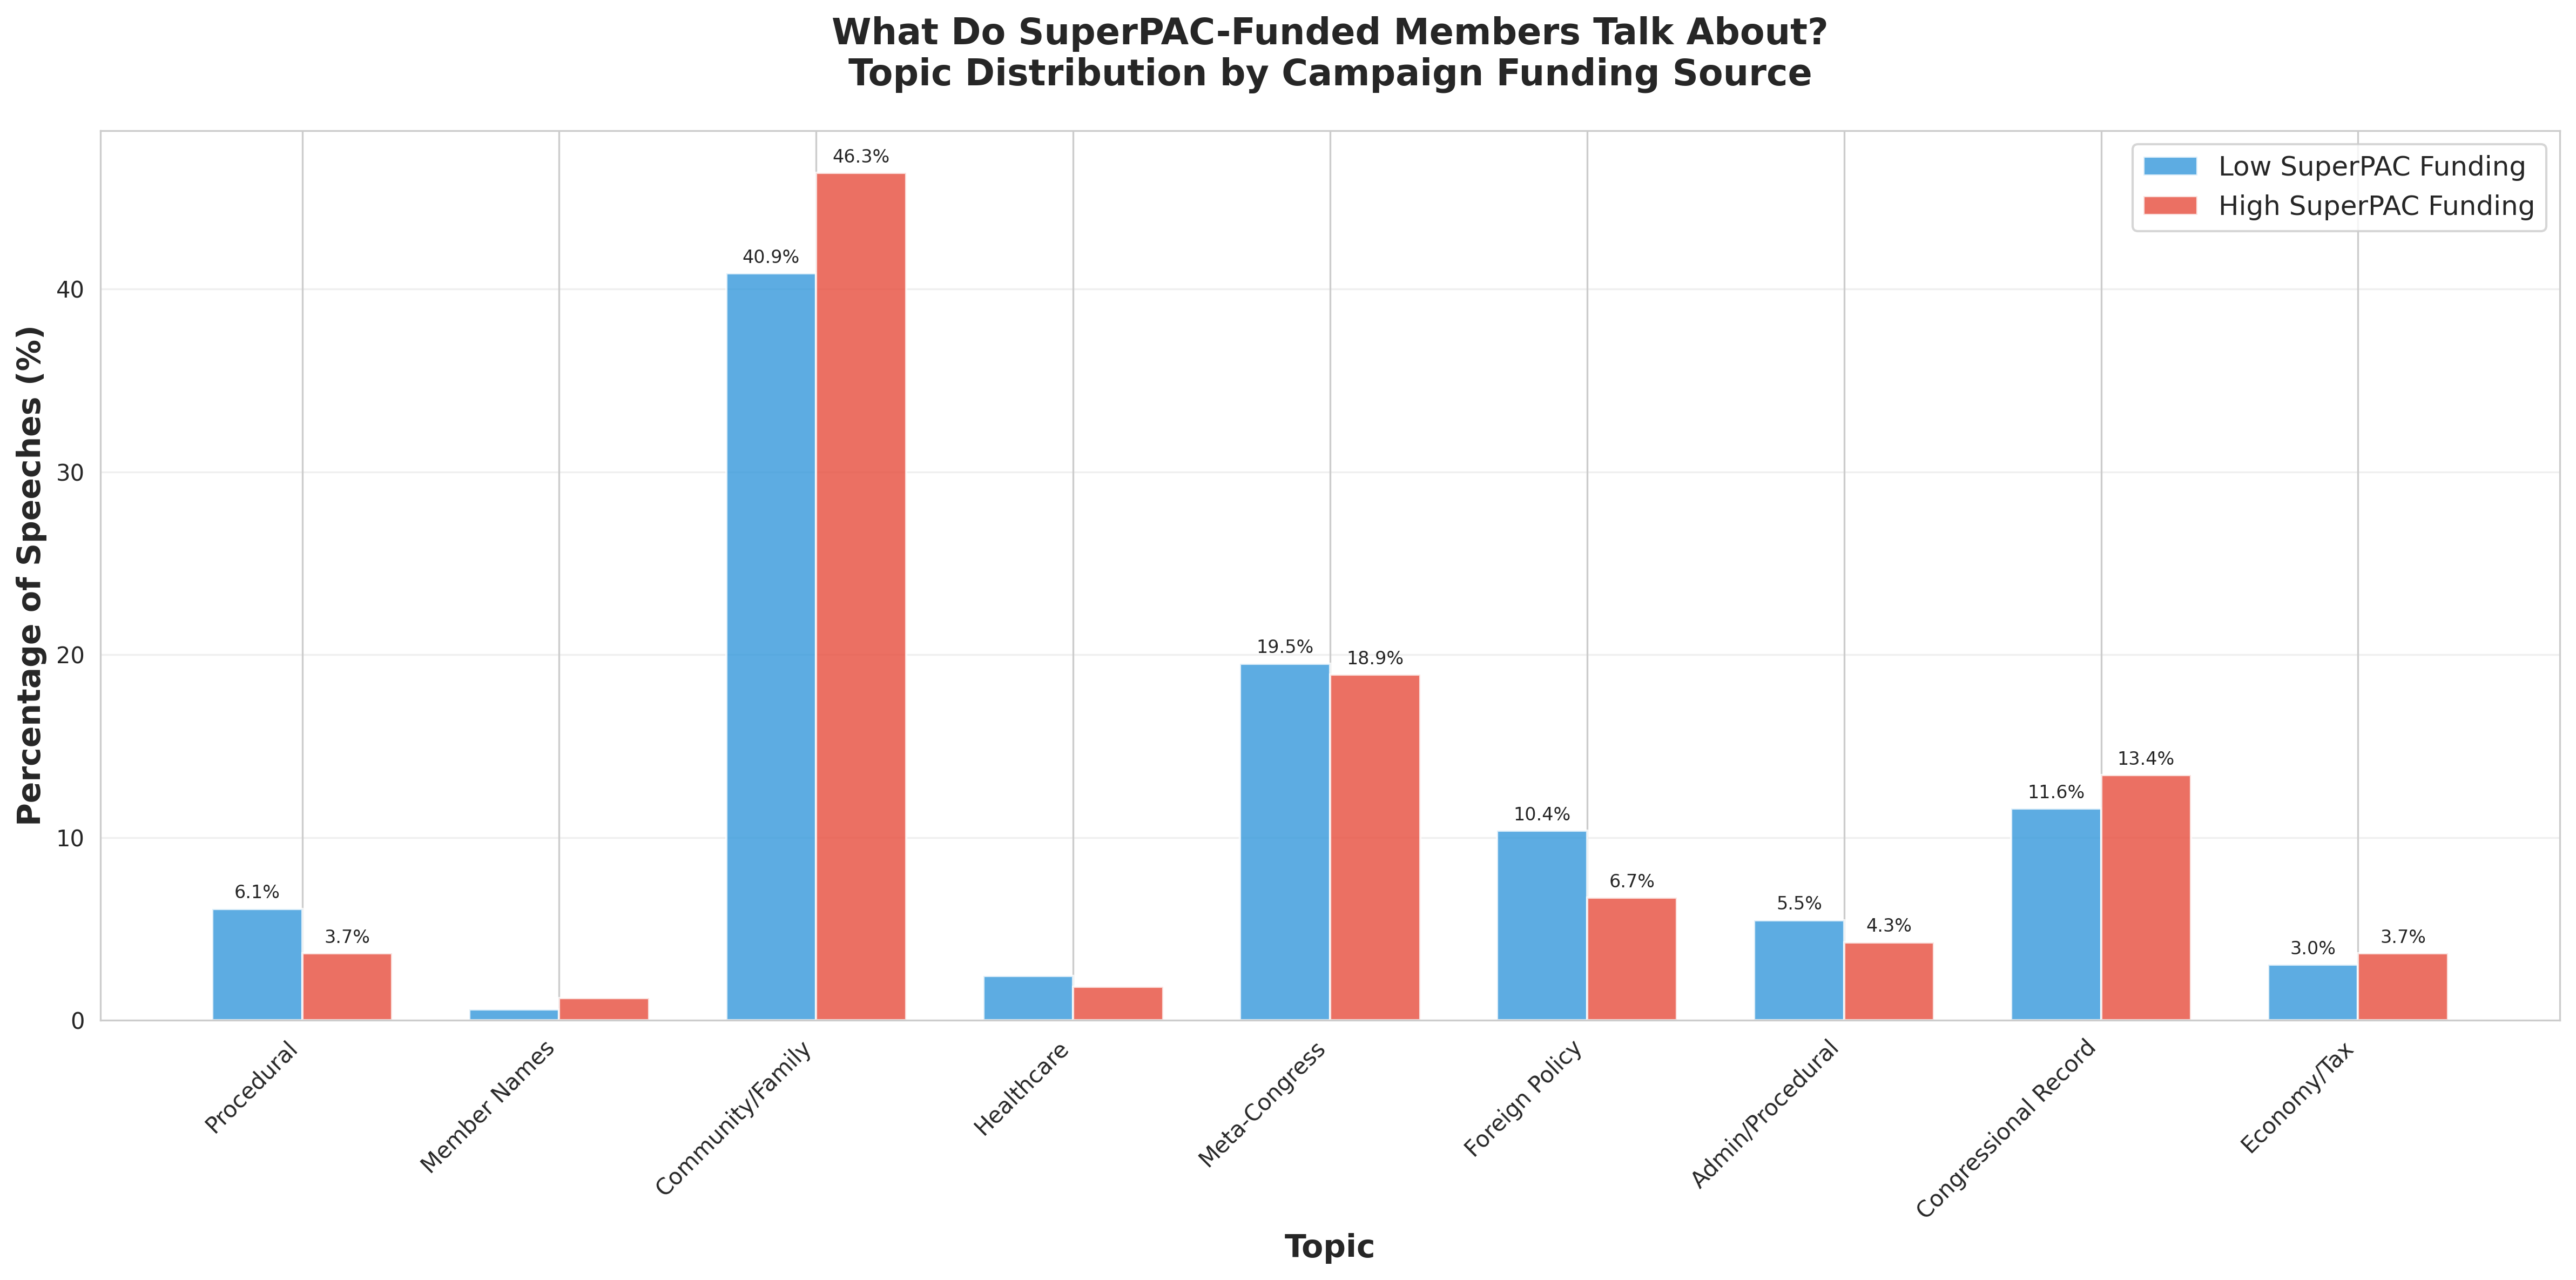

✅ Saved: topic_distribution_superpac.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

# =========================================
# YOUR DATA (10 topics total, 0-9)
# =========================================

# Topic labels
topic_labels = [
    "Procedural",           # 0: shall, title, sec, following, committee
    "Member Names",         # 1: pro, tempore, lee, jackson (likely procedural)
    "Community/Family",     # 2: community, school, honor, life, service
    "Healthcare",           # 3: veterans, health, care, military, women
    "Meta-Congress",        # 4: congress, committee, just, colleagues
    "Foreign Policy",       # 5: border, israel, american, world, children
    "Admin/Procedural",     # 6: committee, rule, sec, public
    "Congressional Record", # 7: sep, record, congressional (procedural)
    "Economy/Tax",          # 8: energy, american, percent, debt, tax
]

low_superpac = np.array([
    0.060976,  # Topic 0
    0.006098,  # Topic 1
    0.408537,  # Topic 2
    0.024390,  # Topic 3
    0.195122,  # Topic 4
    0.103659,  # Topic 5
    0.054878,  # Topic 6
    0.115854,  # Topic 7
    0.030488   # Topic 8
])

high_superpac = np.array([
    0.036585,  # Topic 0
    0.012195,  # Topic 1
    0.463415,  # Topic 2
    0.018293,  # Topic 3
    0.189024,  # Topic 4
    0.067073,  # Topic 5
    0.042683,  # Topic 6
    0.134146,  # Topic 7
    0.036585   # Topic 8
])

topic_labels = topic_labels[:9]

fig, ax = plt.subplots(figsize=(16, 8))  # Made wider to fit labels

x = np.arange(len(low_superpac))
width = 0.35

bars1 = ax.bar(x - width/2, low_superpac * 100, width,
               label='Low SuperPAC Funding', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, high_superpac * 100, width,
               label='High SuperPAC Funding', color='#e74c3c', alpha=0.8)

# Customize
ax.set_xlabel('Topic', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of Speeches (%)', fontsize=14, fontweight='bold')
ax.set_title('What Do SuperPAC-Funded Members Talk About?\nTopic Distribution by Campaign Funding Source',
             fontsize=16, fontweight='bold', pad=20)

# FIX: Use topic_labels instead of "T0", "T1", etc
ax.set_xticks(x)
ax.set_xticklabels(topic_labels, fontsize=10, rotation=45, ha='right')  # Rotated for readability

ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 3:  # Only label bars > 3%
            ax.annotate(f'{height:.1f}%',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.savefig('topic_distribution_superpac.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: topic_distribution_superpac.png")

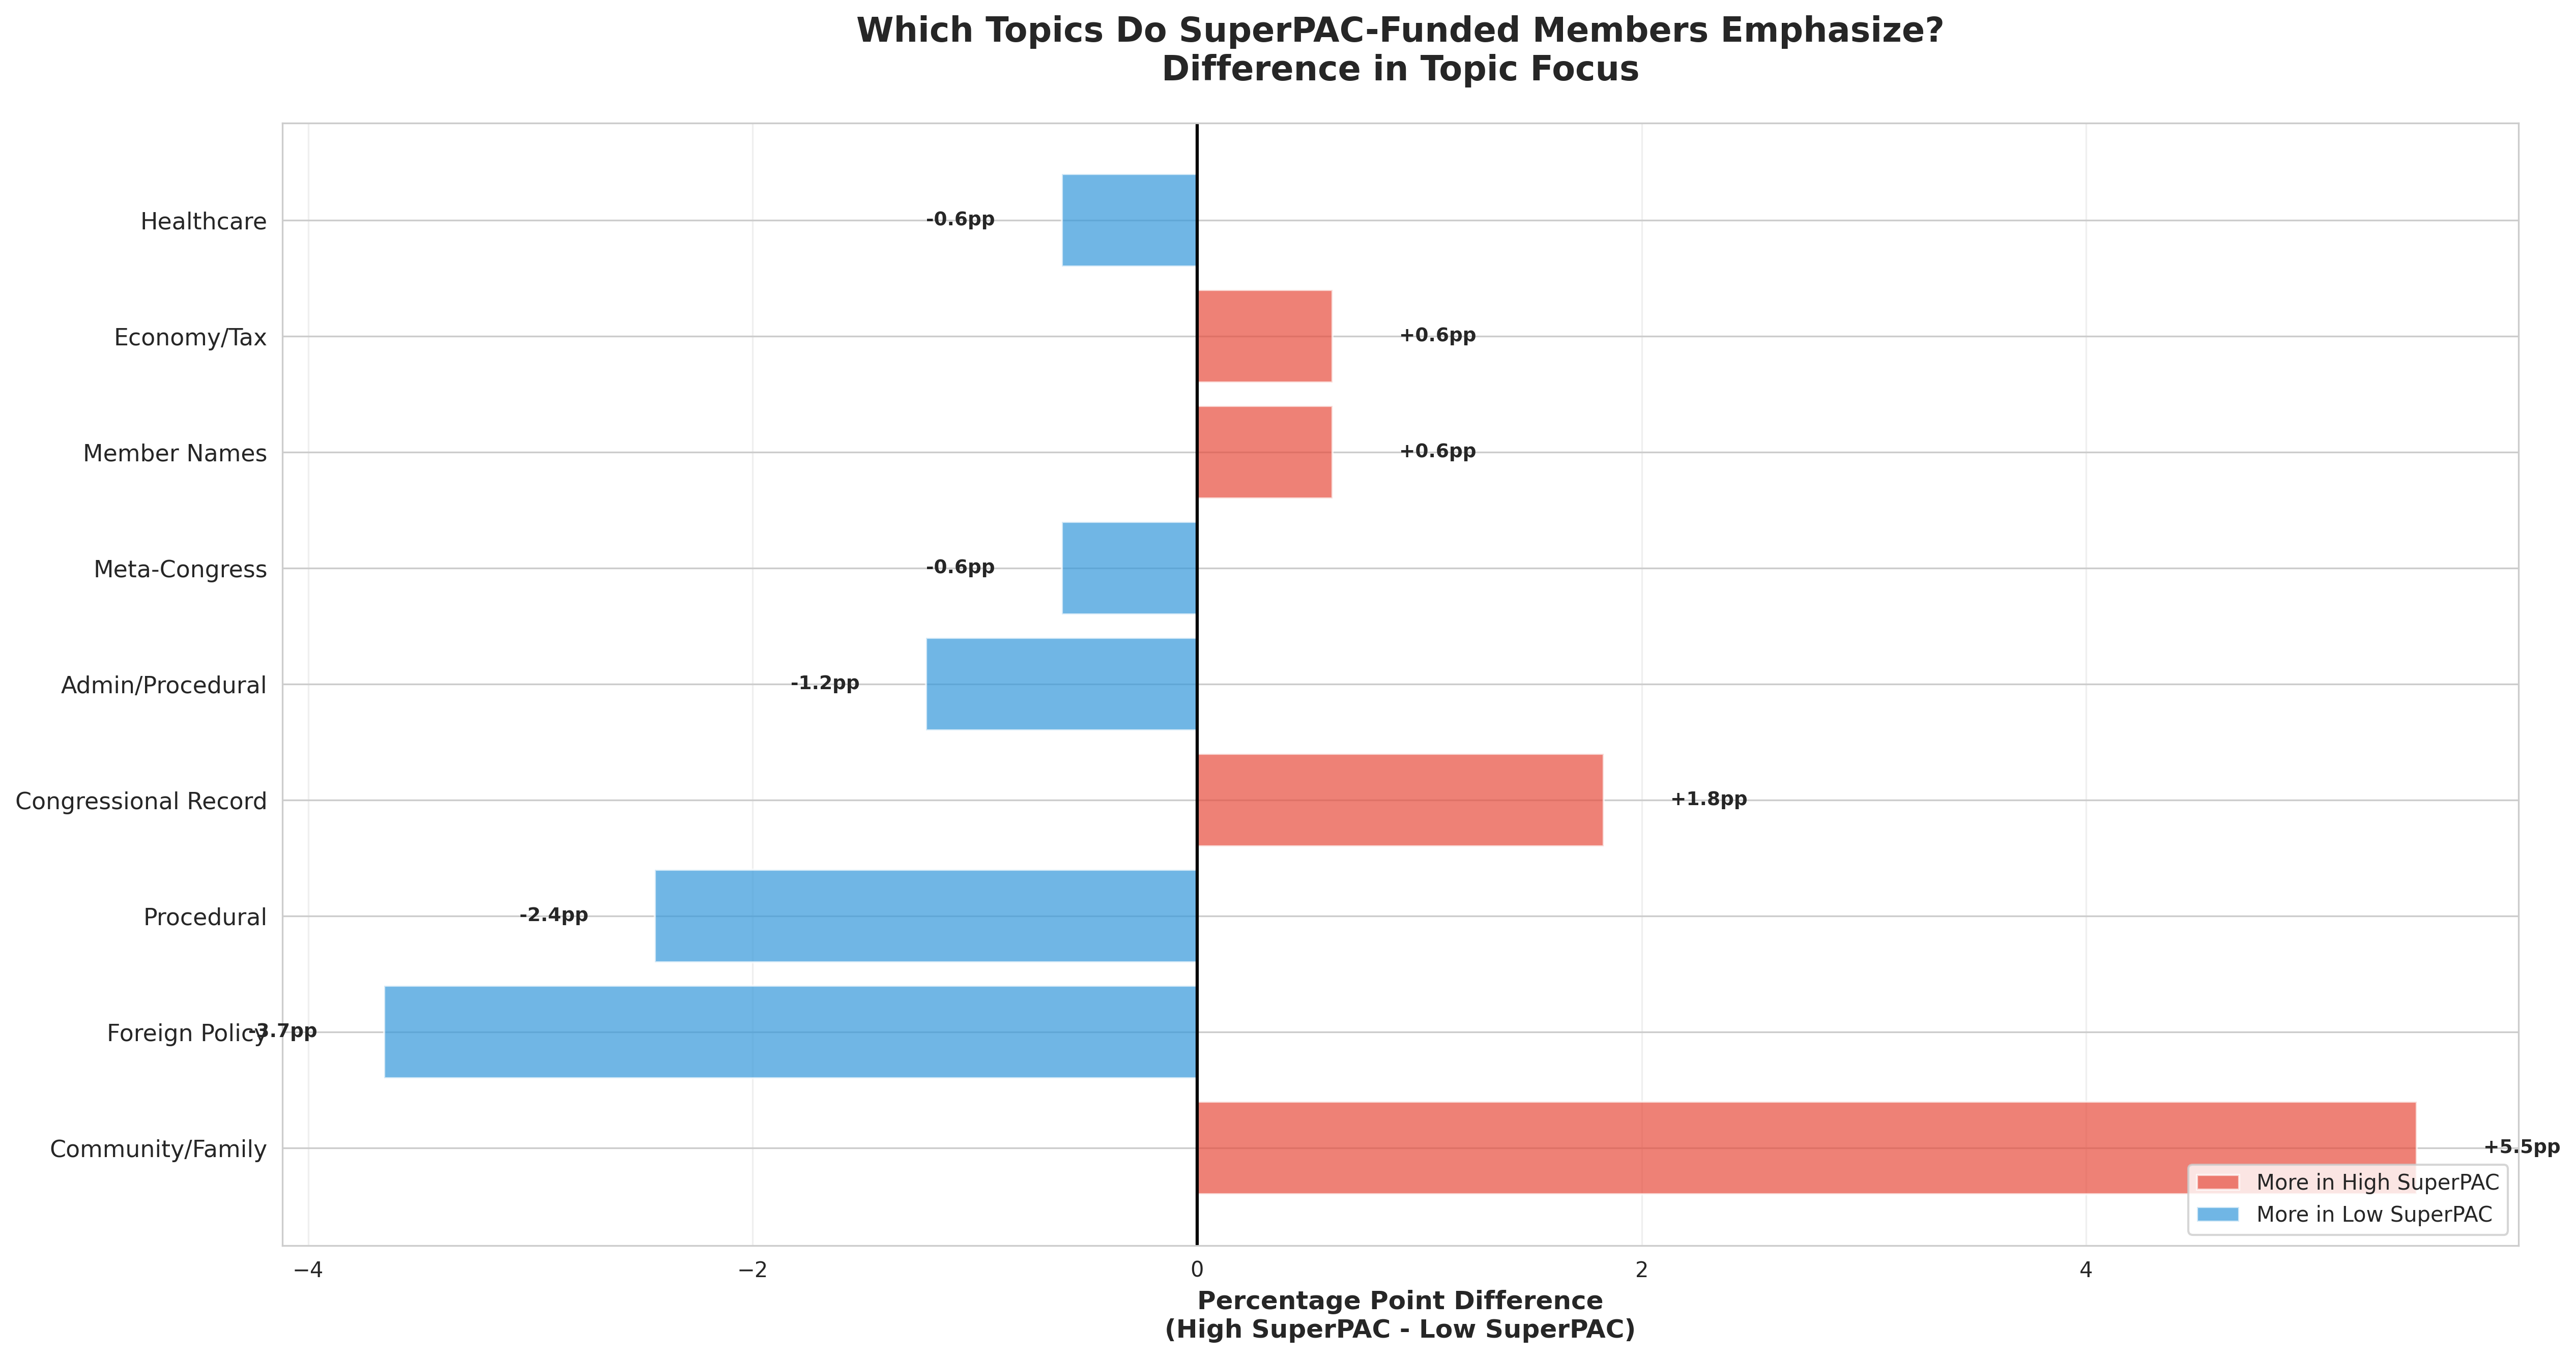

✅ Saved: topic_difference_superpac.png


In [ ]:
fig, ax = plt.subplots(figsize=(17, 9))

differences = (high_superpac - low_superpac) * 100
sorted_indices = np.argsort(np.abs(differences))[::-1]

colors = ['#e74c3c' if d > 0 else '#3498db' for d in differences[sorted_indices]]

bars = ax.barh(range(len(differences)), differences[sorted_indices], color=colors, alpha=0.7)

ax.set_yticks(range(len(differences)))
ax.set_yticklabels([topic_labels[i] for i in sorted_indices], fontsize=11)
ax.set_xlabel('Percentage Point Difference\n(High SuperPAC - Low SuperPAC)',
              fontsize=12, fontweight='bold')
ax.set_title('Which Topics Do SuperPAC-Funded Members Emphasize?\nDifference in Topic Focus',
             fontsize=16, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')
ax.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, differences[sorted_indices])):
    x_pos = val + (0.3 if val > 0 else -0.3)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:+.1f}pp',
            va='center', ha=ha, fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.7, label='More in High SuperPAC'),
    Patch(facecolor='#3498db', alpha=0.7, label='More in Low SuperPAC')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('topic_difference_superpac.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: topic_difference_superpac.png")
